In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
import h5py
import pandas as pd
from scipy.optimize import curve_fit

from topasToDose import getDosemap
from uniformity_fit import *
from partrec_foil_plotting import partrec_foil_plotting
from flatness import *

import tifffile as tiff

In [2]:
def beam_centroid(img,):
    # coordinate grids
    y, x = np.indices(img.shape)

    I = img.astype(float)

    total_intensity = np.nansum(I)

    if total_intensity == 0:
        return None, None  # or fallback to max pixel

    x_centroid = np.nansum(I * x) / total_intensity
    y_centroid = np.nansum(I * y) / total_intensity


    return int(x_centroid), int(y_centroid)

def beam_area_mask(img, fraction, cx,cy):
    peak_val = np.nanmax(img)
    threshold = fraction * peak_val

    # mask of pixels above threshold
    mask = img >= threshold

    return mask

def plot_dose(dosemap, im_type):
    h, w = dosemap.shape
    strip_width = 10

    if im_type == 'RCF':
        pixel_calibration = 0.08467  # mm/pixel
    elif im_type == "YAG":
        pixel_calibration = 0.03
    else:
        raise ValueError("Unknown im_type")

    # Beam centroid in pixel coordinates
    cx, cy = beam_centroid(dosemap)

    # Centered physical coordinates in mm
    x = (np.arange(w) - cx) * pixel_calibration
    y = (np.arange(h) - cy) * pixel_calibration

    # Use integer indices for slicing
    row0 = max(0, cy - strip_width // 2)
    row1 = min(h, cy + strip_width // 2)
    col0 = max(0, cx - strip_width // 2)
    col1 = min(w, cx + strip_width // 2)

    slice_row = np.mean(dosemap[row0:row1, :], axis=0)
    slice_col = np.mean(dosemap[:, col0:col1], axis=1)

    fig, ax_main = plt.subplots(figsize=(10, 6))

    # Image centered at (0, 0)
    im = ax_main.imshow(
        dosemap,
        origin="lower",
        aspect="equal",
        cmap="viridis",
        extent=[x[0], x[-1], y[0], y[-1]]
    )

    # Beam mask and contour
    mask = beam_area_mask(dosemap, 0.85, cx, cy)
    if im_type == 'YAG':
        ax_main.contour(x, y, mask.astype(float), levels=[0.5], colors='white', linewidths=1.6)

    ax_main.set_xlabel("X (mm)")
    ax_main.set_ylabel("Y (mm)")

    # Axes for slices and colorbar
    divider = make_axes_locatable(ax_main)
    ax_x = divider.append_axes("top", size="25%", pad=0.1, sharex=ax_main)
    ax_y = divider.append_axes("right", size="20%", pad=0.1, sharey=ax_main)
    cax  = divider.append_axes("right", size="2%", pad=0.1)

    # Fit the slices
    p0 = [np.max(slice_row)/2, 0, 2, 4]
    p00 = [np.max(slice_row),  4, 2]


    params_x, _ = curve_fit(supergaussian1D, x, slice_row, p0=p0)
    params_y, _ = curve_fit(supergaussian1D, y, slice_col, p0=p0)

    params_xx, _ = curve_fit(sum_2gaussians, x, slice_row, p0=p00)
    params_yy, _ = curve_fit(sum_2gaussians, y, slice_col, p0=p00)

    sig_x, sig_y = params_x[2], params_y[2]
    P_x, P_y = params_x[3], params_y[3]
    r90_x, r90_y = r90(sig_x, P_x), r90(sig_y, P_y)

    # Top plot: X slice
    ax_x.plot(x, slice_row, 'k-', linewidth=3,)
    ax_x.plot( x,supergaussian1D(x, *params_x),  'r-',label=f"SuperGaussian Fit (P={params_x[3]:.2f}, r90={r90_x:.2f})")
    ax_x.plot(x, sum_2gaussians(x, *params_xx), 'g-', label=f"2-Gaussian Fit (x0/sigma={abs(params_xx[1])/params_xx[2]:.2f})")
    ax_x.set_ylabel("Dose")
    ax_x.legend(loc='lower left')
    plt.setp(ax_x.get_xticklabels(), visible=False)

    # Right plot: Y slice
    ax_y.plot(slice_col, y, 'k-', linewidth=3)
    ax_y.plot(supergaussian1D(y, *params_y), y,  'r-',label=f"SuperGaussian Fit (P={params_y[3]:.2f}, r90={r90_y:.2f})")
    ax_y.plot(sum_2gaussians(y, *params_yy),y, 'g-', label=f"2-Gaussian Fit (x0/sigma={abs(params_yy[1])/params_yy[2]:.2f})")
    ax_y.set_xlabel("Dose")
    ax_y.legend(loc='lower right')
    plt.setp(ax_y.get_yticklabels(), visible=False)

    # Colorbar
    fig.colorbar(im, cax=cax, orientation='vertical', label="Dose (Gy)")

    # Centered slice bands on main image
    rect_h = Rectangle(
        (x[0], y[row0]),
        x[-1] - x[0],
        (row1 - row0) * pixel_calibration,
        edgecolor="white", facecolor="none",linewidth=1.5,linestyle="--")

    rect_v = Rectangle(
        (x[col0], y[0]),
        (col1 - col0) * pixel_calibration,
        y[-1] - y[0],
        edgecolor="white",facecolor="none",linewidth=1.5,linestyle="--")

    ax_main.add_patch(rect_h)
    ax_main.add_patch(rect_v)

    # Make sure shared limits align
    ax_x.set_xlim(ax_main.get_xlim())
    ax_y.set_ylim(ax_main.get_ylim())


In [3]:
file = h5py.File('CLARA_experiments/YAGS/images/CLA-USR-DIA-CAM-01_2026-03-05_15-12-49UTC_20_images_full.hdf', 'r')
# file.visit()
# file.close()|

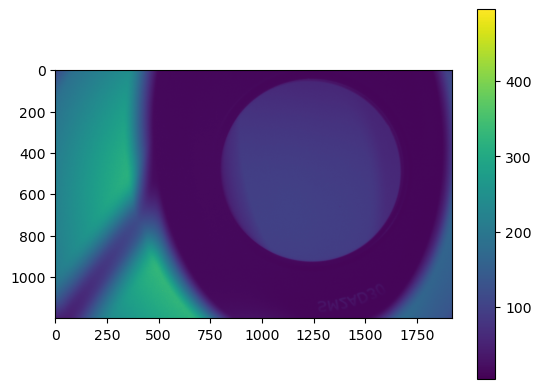

In [162]:
background = h5py.File('CLARA_experiments/YAGS/images/CLA-USR-DIA-CAM-01_2026-03-06_12-34-26UTC_20_images_full.hdf', 'r')
backgroun_arr = np.array(background['Capture000001'])
plt.imshow(backgroun_arr)
plt.colorbar()

In [5]:
file.keys()

<KeysViewHDF5 ['Capture000001', 'Capture000002', 'Capture000003', 'Capture000004', 'Capture000005', 'Capture000006', 'Capture000007', 'Capture000008', 'Capture000009', 'Capture000010', 'Capture000011', 'Capture000012', 'Capture000013', 'Capture000014', 'Capture000015', 'Capture000016', 'Capture000017', 'Capture000018', 'Capture000019', 'Capture000020']>

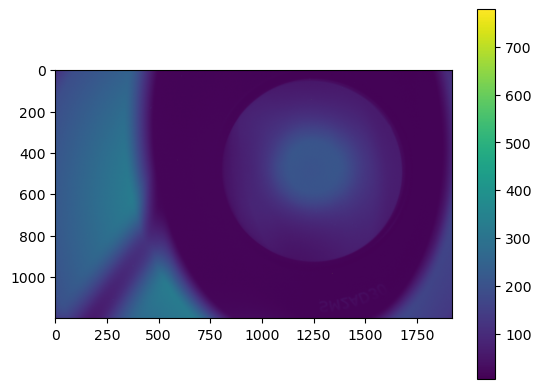

In [159]:
img1 = file['Capture000001']#[250:700,900:1650]
img1_arr = np.array(img1)
# combined = sum(file[key][250:700,900:1650] for key in file.keys())
average = sum(file[key][:] for key in file.keys())/len(file.keys())
plt.imshow(img1_arr)
plt.colorbar()

In [ ]:
img1_arr.

array([[108, 106, 109, ...,  88,  87,  93],
       [104, 105, 107, ...,  94,  93,  96],
       [115, 105,  99, ...,  92,  92,  92],
       ...,
       [142, 135, 141, ..., 117, 112, 112],
       [141, 140, 138, ..., 116, 113, 117],
       [130, 129, 140, ..., 117, 113, 116]],
      shape=(1200, 1920), dtype=uint16)

In [166]:
backgroun_arr 

array([[ 97, 110, 104, ...,  93,  92,  86],
       [104, 105, 105, ...,  86,  93,  92],
       [ 96, 101, 102, ..., 101,  93,  89],
       ...,
       [ 57,  60,  49, ..., 116, 119, 116],
       [ 60,  53,  52, ..., 115, 116, 120],
       [ 50,  50,  54, ..., 117, 115, 113]],
      shape=(1200, 1920), dtype=uint16)

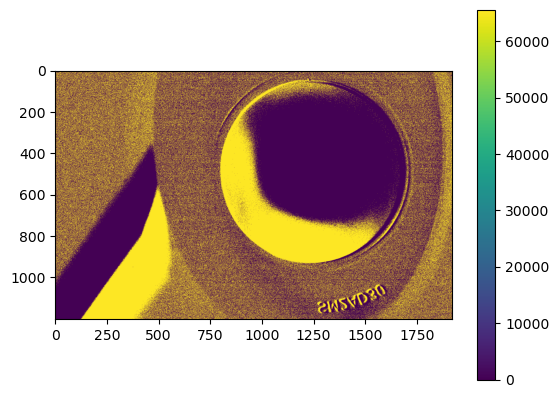

In [161]:
plt.imshow(img1_arr - backgroun_arr)
plt.colorbar()

In [47]:
corrected = combined - sum(background[key][:] for key in background.keys())

(<Figure size 1000x600 with 4 Axes>,
 <Axes: xlabel='X (mm)', ylabel='Y (mm)'>,
 <Axes: ylabel='Dose'>,
 <Axes: xlabel='Dose'>)

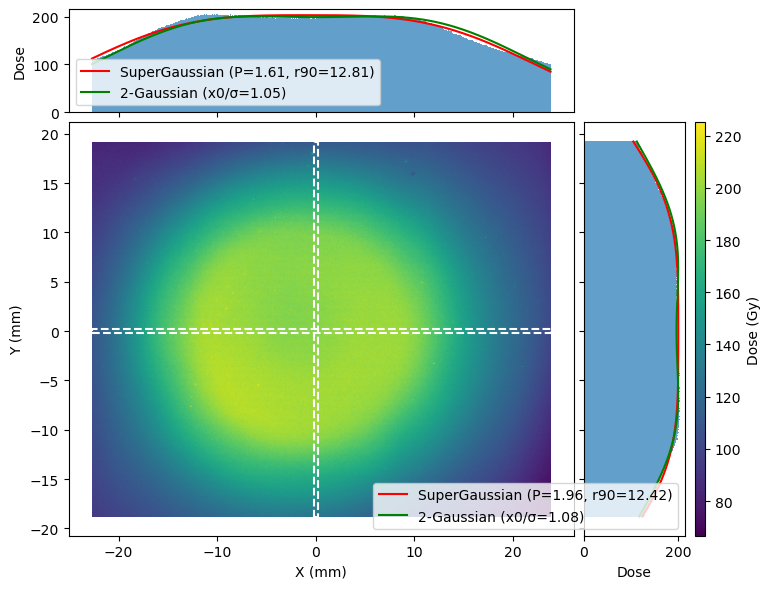

In [ ]:
# plot_dose(average[200:750,900:1600],"YAG")
# plot_dose11(average[250:700,1000:1550],"YAG")
pixel_calibration = 0.08467  # mm/pixel
y,x = np.arange(average[250:700,1000:1550].shape[0])* pixel_calibration, np.arange(average[250:700,1000:1550].shape[1])* pixel_calibration
# print(x,y)
plot_dose11(average[250:700,1000:1550],x,y,strip_width=5, centred=False)


In [ ]:

def beam_area(img, fraction, center):
    peak_val = np.nanmax(img)
    threshold = fraction * peak_val

    # mask of pixels above threshold
    mask = img >= threshold

    # keep image shape (better for geometry)
    new_img = np.zeros_like(img)
    new_img[mask] = img[mask]

    # coordinates
    y, x = np.indices(img.shape)

    cy, cx = center
    r = np.sqrt((x - cx)**2 + (y - cy)**2)

    # mean radius of beam region
    r_mean = np.mean(r[mask])

    return new_img, r_mean

In [8]:
means = []
stds = []

for key in sorted(file.keys()): #guarantees they are processed in numerical order
    img = file[key][:]#[250:700, 900:1650]

    y, x = np.indices(img.shape)

    cx, cy = beam_centroid(img)

    # squared distance (faster than sqrt)
    r2 = (x - cx)**2 + (y - cy)**2

    R60 = beam_area(img, 0.6, cx, cy)

    mask = r2 <= R60**2

    mean_dose = np.nanmean(img[mask])
    std_dose = np.nanstd(img[mask])

    means.append(mean_dose)
    stds.append(std_dose)

TypeError: beam_area() takes 3 positional arguments but 4 were given

In [ ]:
means,stds

([np.float64(187.22455969050736),
  np.float64(200.07234212199248),
  np.float64(201.46568111839966),
  np.float64(171.9484591828938),
  np.float64(205.05865698729582),
  np.float64(158.6864856889938),
  np.float64(189.88238814780806),
  np.float64(203.7654170321498),
  np.float64(206.00607413370412),
  np.float64(204.9720167607943)],
 [np.float64(23.67840253648773),
  np.float64(13.38530854621843),
  np.float64(6.396776750246859),
  np.float64(29.55884864434986),
  np.float64(5.96195198886665),
  np.float64(38.074841465611904),
  np.float64(20.451868828207257),
  np.float64(6.22173967849886),
  np.float64(6.170794705388602),
  np.float64(5.964272412747059)])

In [9]:

masked_img = np.zeros_like(img)
masked_img[mask] = img[mask]

# plt.imshow(masked_img)
plt.imshow(img)
plt.contour(mask, colors='white')

NameError: name 'mask' is not defined

uint16
(3659, 4950, 3)
3242 65535


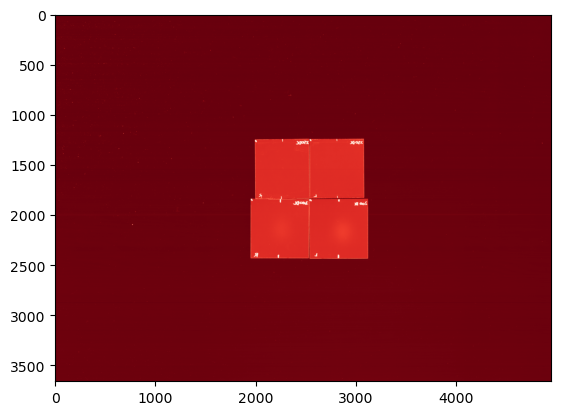

In [9]:
channel = 0
if channel == 1:
    cmap = 'Greens'

elif channel ==0:
    cmap = "Reds"

arr = tiff.imread("CLARA_experiments/CLARA_films/Film Scans/DC/CLARA_DC_250_200_MeV_2026_12_03.tif")
print(arr.dtype)
print(arr.shape)
print(arr.min(), arr.max())
plt.imshow(arr[:,:,channel],cmap=cmap)

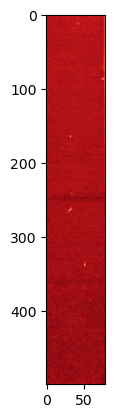

In [10]:
film_no_dose = tiff.imread("CLARA_experiments/CLARA_films/Film Scans/DC/CLARA_DC_250_200_MeV_2026_12_03.tif")
plt.imshow(film_no_dose[1300:1800,3000:3080,channel],cmap = cmap)
# print(film_no_dose.mode)  # 'RGB' is usually 8-bit per channel



(np.uint16(46955), np.uint16(3242))

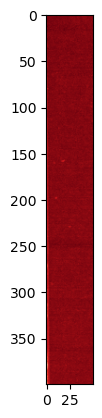

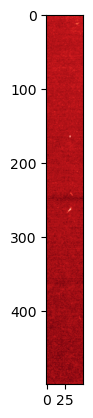

In [97]:
plt.imshow(film_no_dose[1300:1700,2000:2050,channel],cmap=cmap) #strip on the left
plt.figure()
plt.imshow(film_no_dose[1300:1800,3000:3050,channel],cmap = cmap)
np.max(film_no_dose[1300:1700,2005:2050,channel]), np.min(film_no_dose)

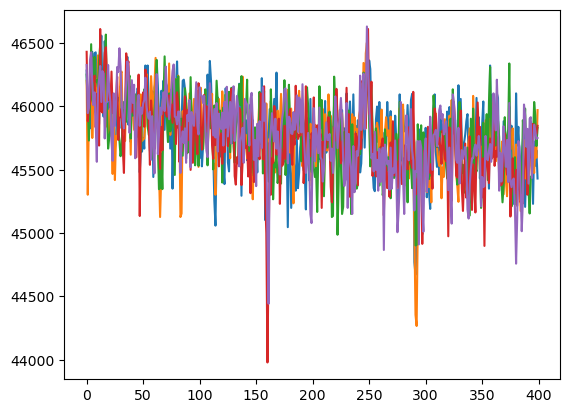

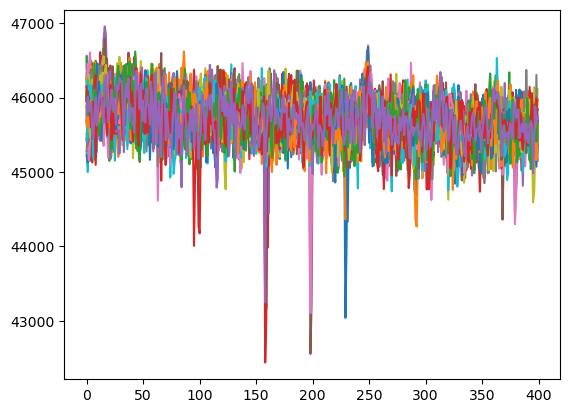

In [98]:
plt.plot(film_no_dose[1300:1700,2005:2010,channel])
np.mean(film_no_dose[1300:1700,2005:2010,channel])
plt.figure()
plt.plot(film_no_dose[1300:1700,2005:2050,channel])

In [99]:
OD0_green = -np.log(np.mean(film_no_dose[1300:1700,2005:2010,1])/65535)
OD0_red = -np.log(np.mean(film_no_dose[1300:1700,2005:2010,0])/65535)
OD0_green,OD0_red

(np.float64(0.41050102181223663), np.float64(0.3590792095420539))

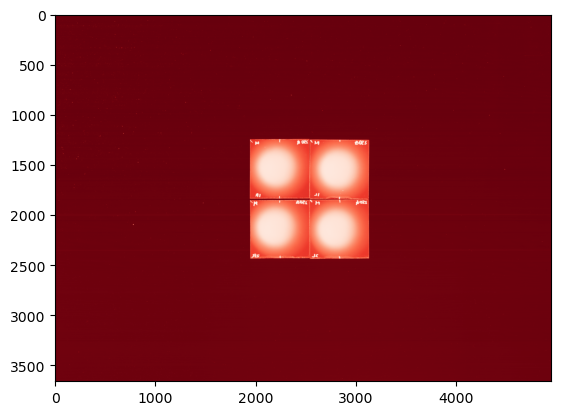

In [139]:
filename = 'CLARA_250Q_M_2026_12_03'
films = tiff.imread(f"CLARA_experiments/CLARA_films/Film Scans/250Q/{filename}.tif")
#("CLARA_experiments/CLARA_films/Film Scans/250S/CLARA_250S_B_2026_12_03.tif")
plt.imshow(films[:,:,channel],cmap = cmap)
# films.show()  # display image
# flipped_h = films.transpose(Image.FLIP_LEFT_RIGHT)

film_array = np.array(films)

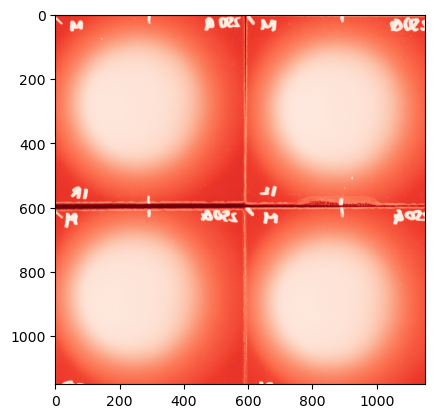

In [140]:
plt.imshow(film_array[1250:2400,1950:3100,channel],cmap=cmap)

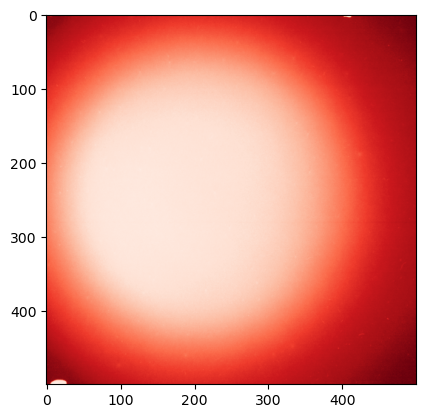

In [150]:
film1 = film_array[1250:1800,1950:2500,channel]
film2 = film_array[1300:1800,2550:3100,channel]
film3 = film_array[1900:2400,1950:2500,channel]
film4 = film_array[1900:2400,2600:3100,channel]



plt.imshow(film4,cmap=cmap)


In [138]:
np.save(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film1.npy', film1)
np.save(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film2.npy', film2)
np.save(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film3.npy', film3)
np.save(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film4.npy', film4)

NameError: name 'dosemap' is not defined

In [104]:
film_array.shape


(3659, 4950, 3)

In [105]:
film_array.min(), film_array.max()

(np.uint16(2713), np.uint16(65535))